![insomnia](insomnia.jpg)


Your client, SleepInc, has shared anonymized sleep data from their hot new sleep tracking app SleepScope. As their data science consultant, your mission is to analyze the lifestyle survey data with Python to discover relationships between exercise, gender, occupation, and sleep quality. See if you can identify patterns leading to insights on sleep quality.

## 💾 The data: sleep_health_data.csv

SleepInc has provided you with an anonymized dataset of sleep and lifestyle metrics for 374 individuals. This dataset contains average values for each person calculated over the past six months. The data is saved as `sleep_health_data.csv`.

The dataset includes 13 columns covering sleep duration, quality, disorders, exercise, stress, diet, demographics, and other factors related to sleep health. 

| Column | Description |
|---------|----------------------------------------|  
| `Person ID` | An identifier for each individual. |
| `Gender` | The gender of the person (Male/Female). |  
| `Age` | The age of the person in years. |
| `Occupation` | The occupation or profession of the person. |
| `Sleep Duration (hours)` | The average number of hours the person sleeps per day. |
| `Quality of Sleep (scale: 1-10)` | A subjective rating of the quality of sleep, ranging from 1 to 10. |
| `Physical Activity Level (minutes/day)` | The average number of minutes the person engages in physical activity daily. |  
| `Stress Level (scale: 1-10)` | A subjective rating of the stress level experienced by the person, ranging from 1 to 10. |
| `BMI Category` | The BMI category of the person (e.g., Underweight, Normal, Overweight). |
| `Blood Pressure (systolic/diastolic)` | The average blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure. |
| `Heart Rate (bpm)` | The average resting heart rate of the person in beats per minute. |
| `Daily Steps` | The average number of steps the person takes per day. |
| `Sleep Disorder` | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea). |

In [66]:
# Start coding here
# Use as many cells as you need
import pandas as pd

In [67]:
sleep_df = pd.read_csv('sleep_health_data.csv')
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

display(sleep_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


None

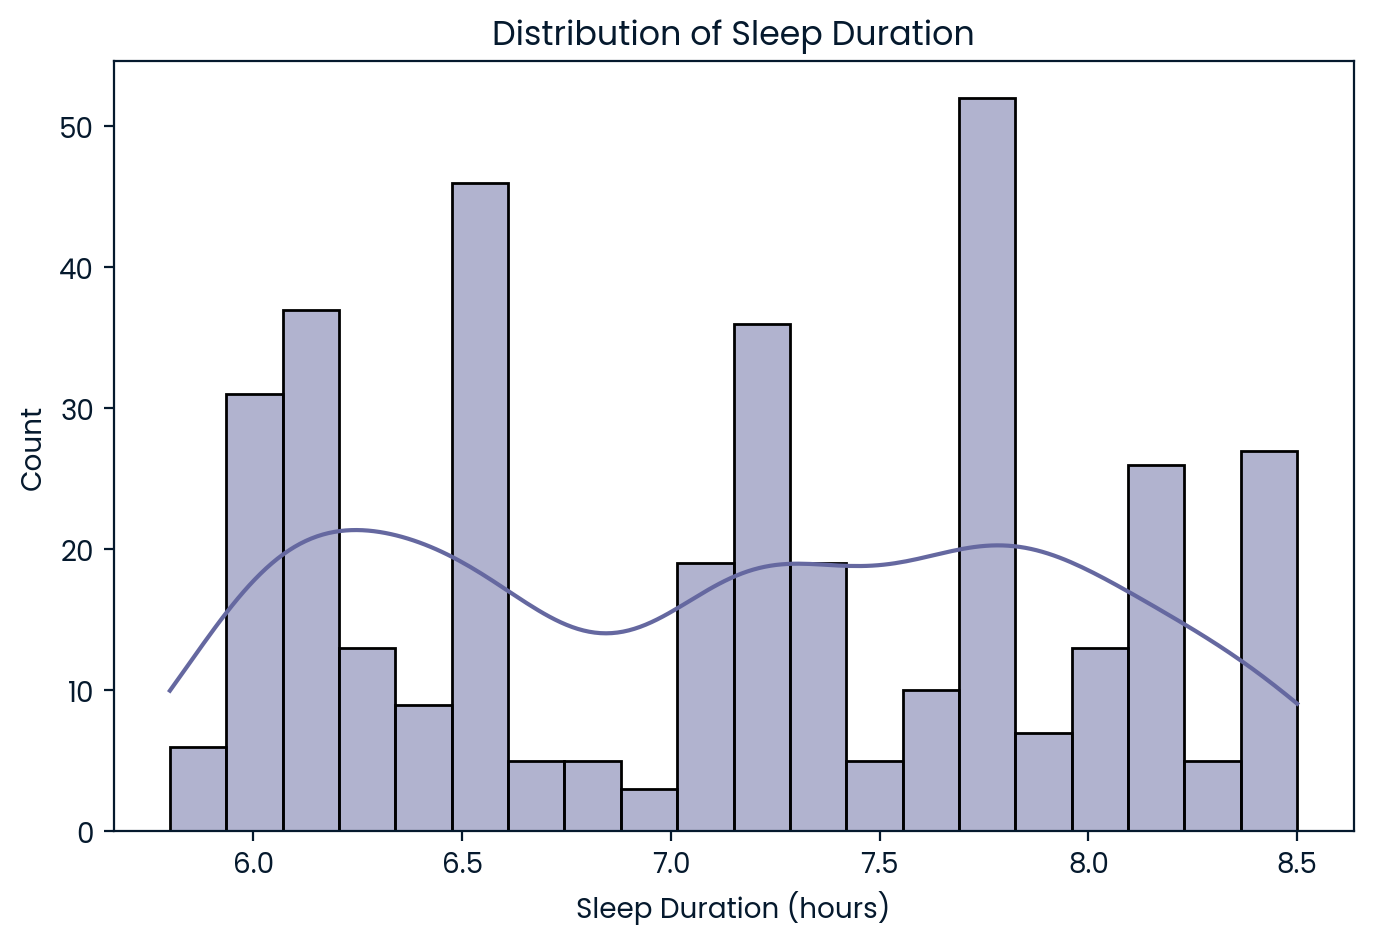

In [83]:
# Visualize distribution of Sleep Duration
plt.figure(figsize=(8, 5))
sns.histplot(sleep_df['Sleep Duration'], kde=True, bins=20)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Count')
plt.show()

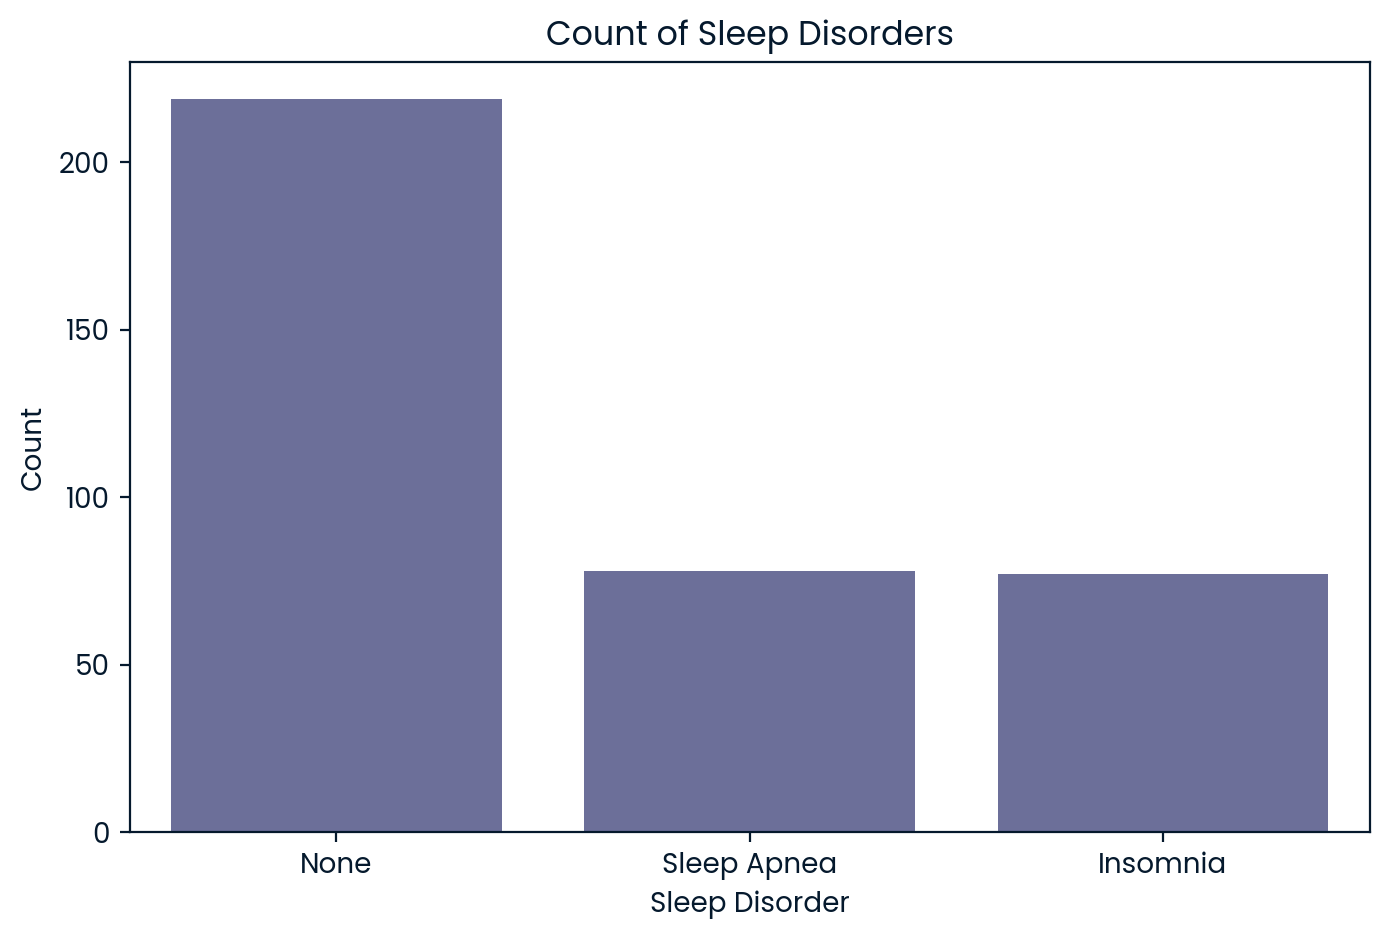

In [84]:
# Visualize count of Sleep Disorders
plt.figure(figsize=(8, 5))
sns.countplot(data=sleep_df, x='Sleep Disorder', order=sleep_df['Sleep Disorder'].value_counts().index)
plt.title('Count of Sleep Disorders')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.show()

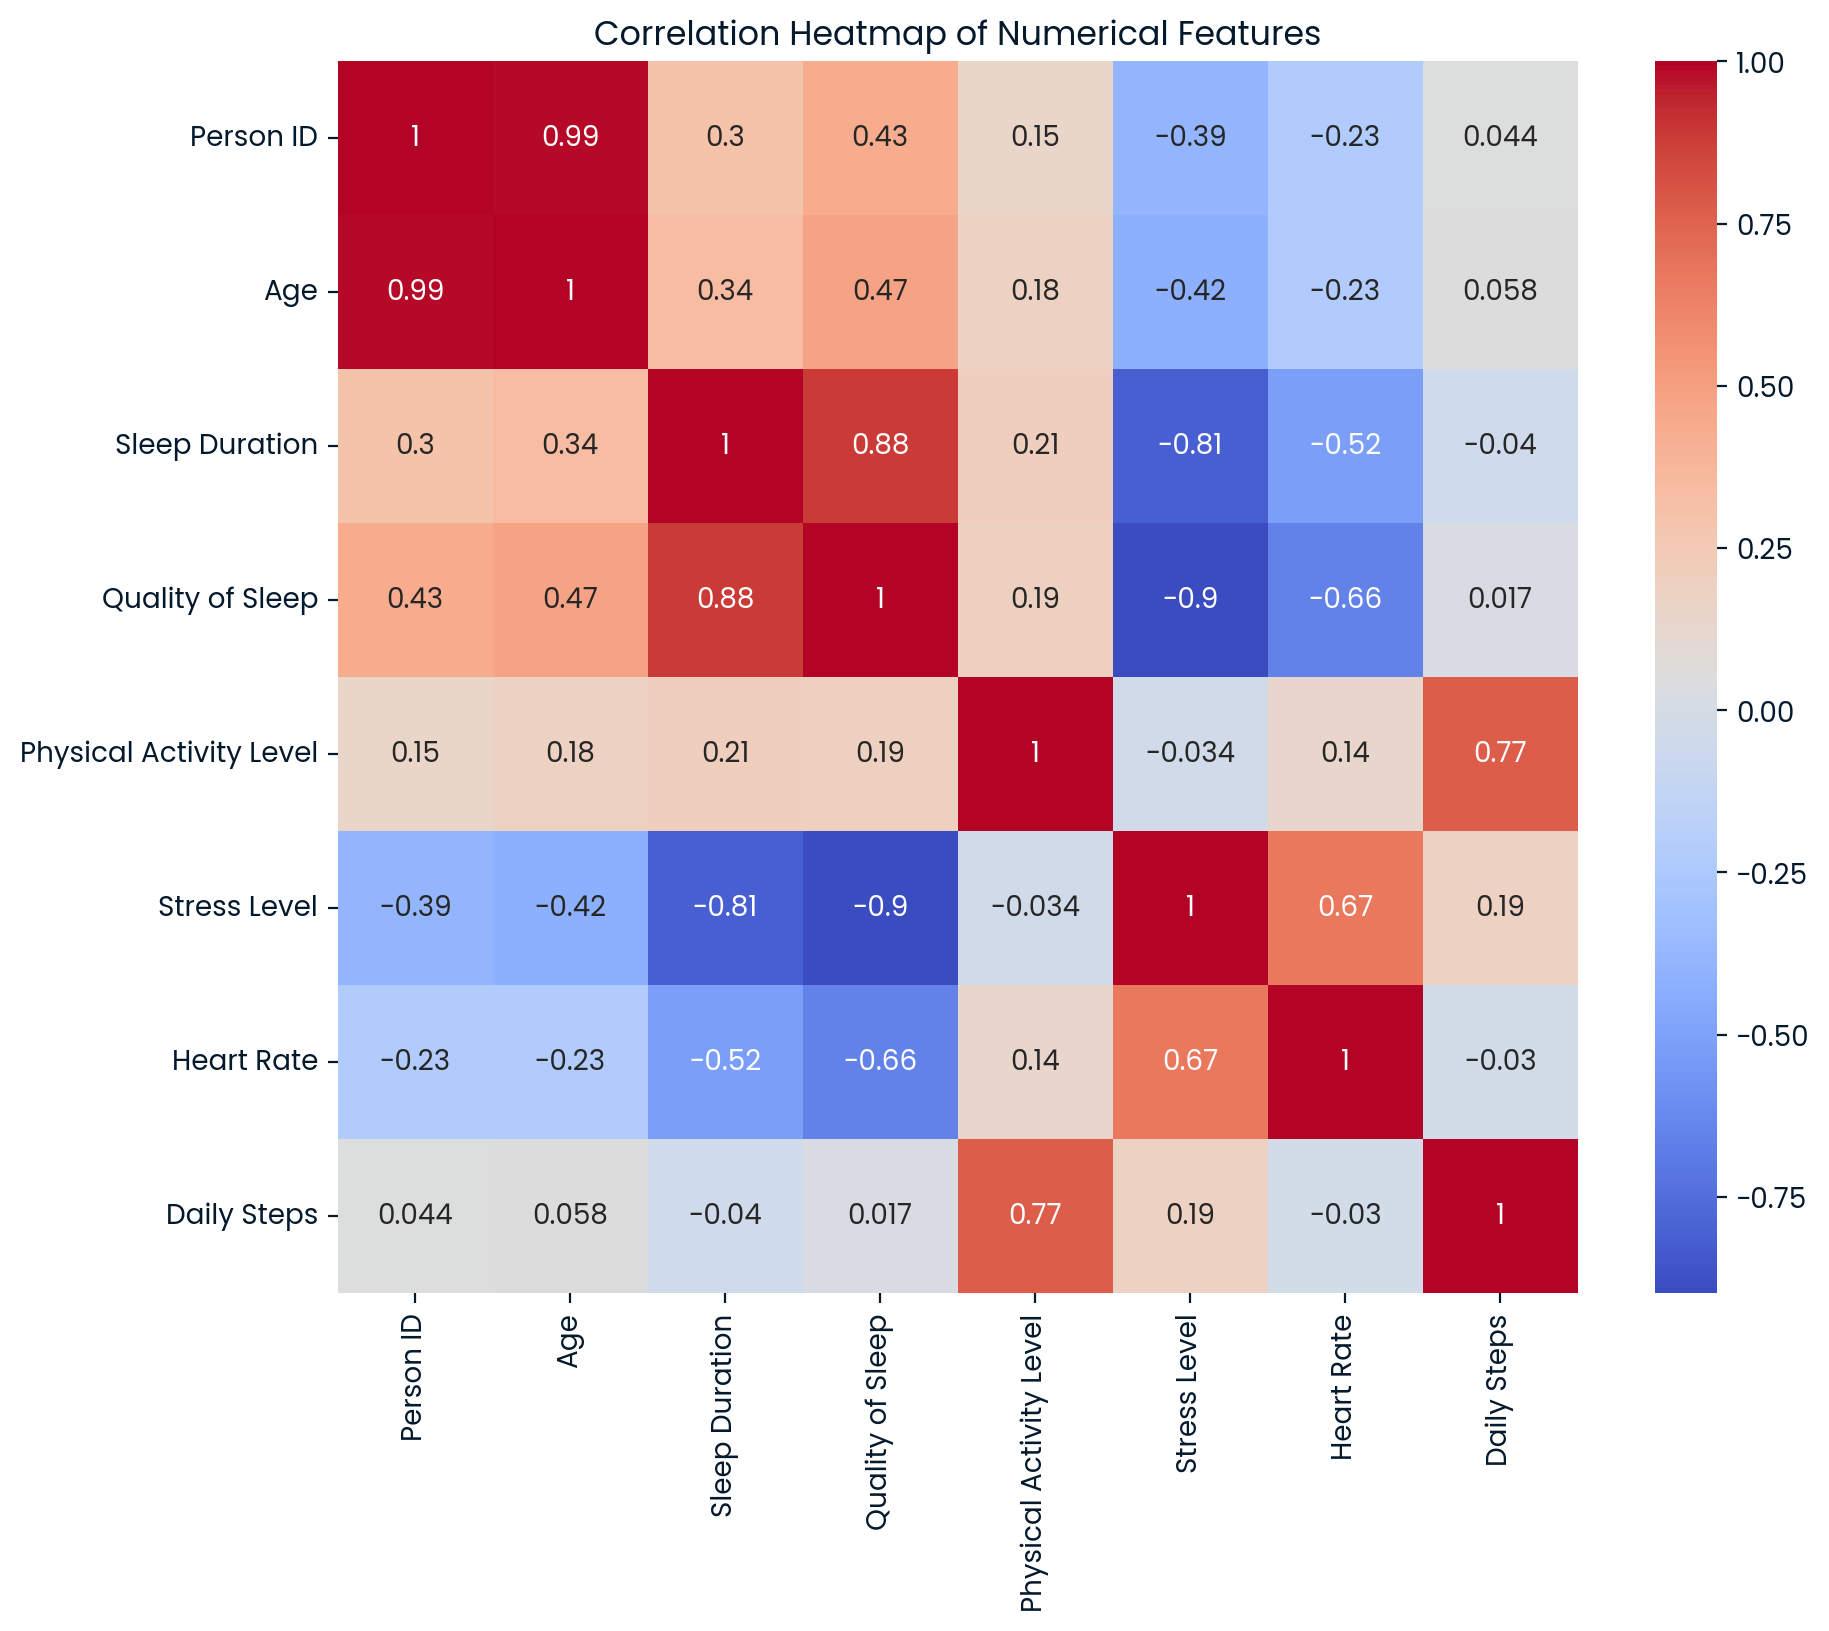

In [85]:
# Correlation heatmap of numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(sleep_df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [68]:
sleep_duration = sleep_df.groupby('Occupation')['Sleep Duration'].mean()
sleep_duration

Occupation
Accountant              7.113514
Doctor                  6.970423
Engineer                7.987302
Lawyer                  7.410638
Manager                 6.900000
Nurse                   7.063014
Sales Representative    5.900000
Salesperson             6.403125
Scientist               6.000000
Software Engineer       6.750000
Teacher                 6.690000
Name: Sleep Duration, dtype: float64

In [69]:
lowest_sleep_occ = sleep_duration.sort_values().index[0]
lowest_sleep_occ

'Sales Representative'

In [70]:
sleep_quality = sleep_df.groupby('Occupation')['Quality of Sleep'].mean()  
sleep_quality

Occupation
Accountant              7.891892
Doctor                  6.647887
Engineer                8.412698
Lawyer                  7.893617
Manager                 7.000000
Nurse                   7.369863
Sales Representative    4.000000
Salesperson             6.000000
Scientist               5.000000
Software Engineer       6.500000
Teacher                 6.975000
Name: Quality of Sleep, dtype: float64

In [71]:
lowest_sleep_quality_occ = sleep_quality.sort_values().index[0]
lowest_sleep_quality_occ

'Sales Representative'

In [72]:
if lowest_sleep_occ == lowest_sleep_quality_occ:
  same_occ = True
else:
  same_occ = False

In [73]:
# Filter the full dataframe to only rows where BMI Category is Normal and Sleep Disorder is Insomnia.
normal = sleep_df[(sleep_df["BMI Category"] == "Normal") &  
                  (sleep_df["Sleep Disorder"] == "Insomnia")]
normal2 = sleep_df[(sleep_df["BMI Category"] == "Normal Weight") &  
                  (sleep_df["Sleep Disorder"] == "Insomnia")]

In [74]:
# Total normal rows               
total_normal = len(sleep_df[sleep_df["BMI Category"] == "Normal"])  
# Calculate normal insomnia ratio               
normal_insomnia_ratio = round(len(normal) / total_normal, 2) 
normal_insomnia_ratio

0.04

In [75]:
# Filter the full dataframe to only rows where BMI Category is Overweight and Sleep Disorder is Insomnia.
overweight = sleep_df[(sleep_df["BMI Category"] == "Overweight") &   
                      (sleep_df["Sleep Disorder"] == "Insomnia")]  
# Total overweight rows
total_overweight = len(sleep_df[sleep_df["BMI Category"] == "Overweight"])  
# Calculate overweight insomnia ratio 
overweight_insomnia_ratio = round(len(overweight) / total_overweight, 2)
overweight_insomnia_ratio

0.43

In [76]:
# Filter the full dataframe to only rows where BMI Category is Obese and Sleep Disorder is Insomnia.
obese = sleep_df[(sleep_df["BMI Category"] == "Obese") &  
                  (sleep_df["Sleep Disorder"] == "Insomnia")]
# Total obese rows          
total_obese = len(sleep_df[sleep_df["BMI Category"] == "Obese"])  
# Calculate obese insomnia ratio
obese_insomnia_ratio = round(len(obese) / total_obese, 2)
obese_insomnia_ratio

0.4

In [77]:
bmi_insomnia_ratios = {
    "Normal": normal_insomnia_ratio,  
    "Overweight": overweight_insomnia_ratio,
    "Obese": obese_insomnia_ratio 
}
bmi_insomnia_ratios

{'Normal': 0.04, 'Overweight': 0.43, 'Obese': 0.4}